# Section 1: Dataset Understanding & Structural Integrity

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
os.chdir("..")
# 2. Configure high-fidelity pandas viewing options
pd.set_option('display.max_columns', None)

DB_PATH = os.getenv("DB_PATH", "../data/ml_project.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM raw_data", conn)
conn.close()

print(f"Total Patient Records: {df.shape[0]}")
print(f"Total Initial Features: {df.shape[1]}")


Total Patient Records: 303
Total Initial Features: 14


In [2]:
print("=== Component Metadata Layout ===")
print(df.dtypes)

print("\n=== Initial Matrix Sample View ===")
display(df.head(5))

=== Component Metadata Layout ===
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

=== Initial Matrix Sample View ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Heart Disease Dataset Features (Compact)

- age: Age of the patient (years)
- sex: Gender (1 = male, 0 = female)
- cp: Type of chest pain
- trestbps: Resting blood pressure (mm Hg)
- chol: Serum cholesterol (mg/dl)
- fbs: Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
- restecg: Resting ECG results
- thalach: Maximum heart rate achieved
- exang: Exercise-induced angina (1 = yes, 0 = no)
- oldpeak: ST depression induced by exercise
- slope: Slope of peak exercise ST segment
- ca: Number of major vessels colored by fluoroscopy
- thal: Thalassemia type
- num: Heart disease presence (target variable)

In [3]:
# mark all ? as nan
df.replace('?', np.nan, inplace=True)

# numerical features
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numerical_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# target feature  to a numeric type
df['num'] = pd.to_numeric(df['num'], errors='coerce')

print("===  Missing Value  ===")
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

missing_values = pd.DataFrame({
    "Raw Missing Count": null_counts,
    "Percentage (%)": null_percentages,
    "Current DataType": df.dtypes
}).sort_values(by="Raw Missing Count", ascending=False)

# Display only features containing actual missing values
display(missing_values[missing_values["Raw Missing Count"] > 0])

===  Missing Value  ===


,Raw Missing Count,Percentage (%),Current DataType
ca,4,1.320132,object
thal,2,0.660066,object


In [4]:
duplicate_records = df.duplicated().sum()
print(f"Data duplication check: Found {duplicate_records} identical rows ")

if duplicate_records > 0:
    df.drop_duplicates(inplace=True)
    print(f"removed duplicates: {df.shape[0]} unique rows remain.")
else:
    print("no duplicates found...")

Data duplication check: Found 0 identical rows 
no duplicates found...


In [5]:
print("=== raw multi-Class severity scales ===\n")
print(df['num'].value_counts().sort_index())

# create a binary target variable: 1 for presence of heart disease (num > 0), 0 for absence (num = 0)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print("\n=== Operational Binary Stratification Balance ===\n")
raw_counts = df['target'].value_counts()
proportions = df['target'].value_counts(normalize=True) * 100

for label, count in raw_counts.items():
    state = "Healthy (0)" if label == 0 else "Sick (1)"
    print(f"{state}: {count} patients ({proportions[label]:.2f}%)")


=== raw multi-Class severity scales ===

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

=== Operational Binary Stratification Balance ===

Healthy (0): 164 patients (54.13%)
Sick (1): 139 patients (45.87%)


In [6]:
# Numerical Feature Summary
display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# Section 2: Detail-Driven Feature Analysis

In [7]:
# Configure premium, publication-grade visualization formatting
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.titlesize': 18,
    'figure.figsize': (12, 8)
})

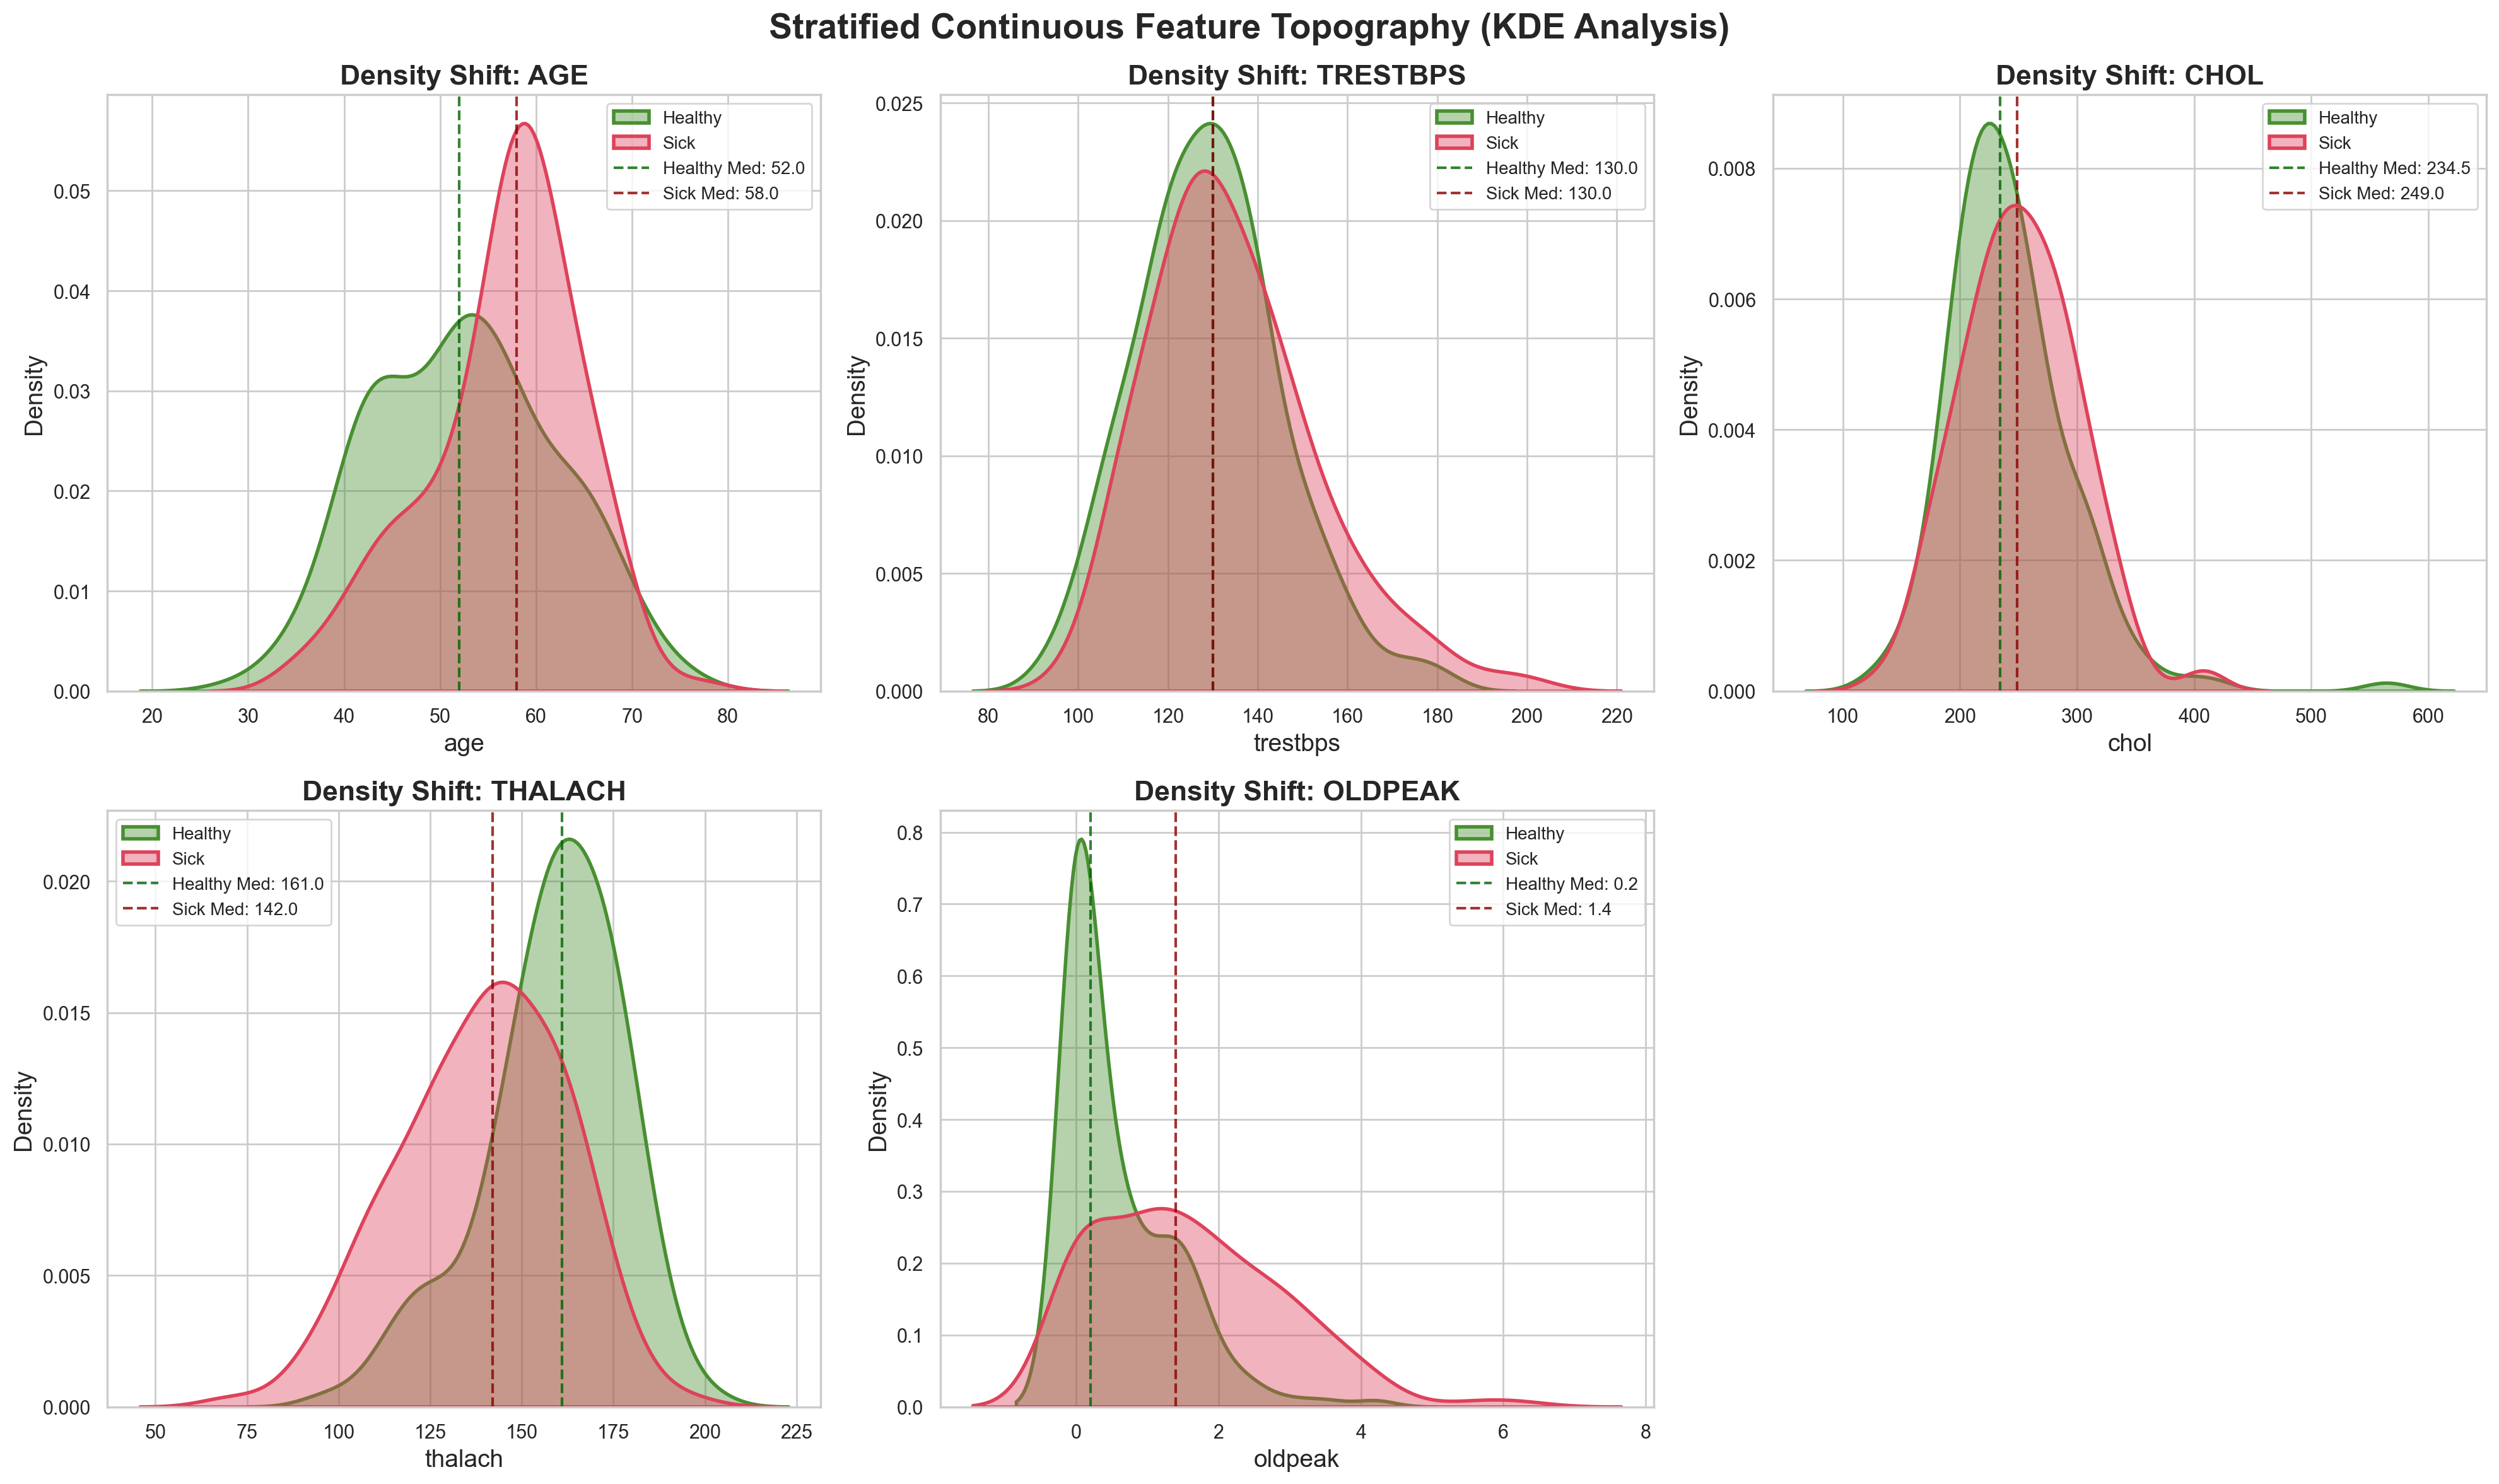

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    # Smooth distribution lines (Green = Healthy, Red = Sick)
    sns.kdeplot(data=df[df['target']==0], x=col, fill=True, color="#488f31", alpha=0.4, label="Healthy", ax=axes[idx], linewidth=2)
    sns.kdeplot(data=df[df['target']==1], x=col, fill=True, color="#de425b", alpha=0.4, label="Sick", ax=axes[idx], linewidth=2)
    
    # Calculate and plot demographic medians
    healthy_med = df[df['target']==0][col].median()
    sick_med = df[df['target']==1][col].median()
    axes[idx].axvline(healthy_med, color="darkgreen", linestyle="--", alpha=0.8, label=f"Healthy Med: {healthy_med:.1f}")
    axes[idx].axvline(sick_med, color="darkred", linestyle="--", alpha=0.8, label=f"Sick Med: {sick_med:.1f}")
    
    axes[idx].set_title(f"Density Shift: {col.upper()}", weight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend(fontsize=10)

fig.delaxes(axes[5]) # Remove the blank 6th grid box to keep the layout crisp
plt.suptitle("Stratified Continuous Feature Topography (KDE Analysis)", weight='bold', fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# outlier dynamics and variance landscape